### Install the libraries

In [3]:
%pip install torch torchvision torchaudio --q
%pip install opencv-python pycocotools matplotlib onnxruntime onnx -q
%pip install torch torchvision -q
%pip install -q 'git+https://github.com/facebookresearch/segment-anything.git'

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [93]:
machine = 'mac-silicon'
#machine = 'colab'

base_path = '../assets'
models_path = '../models'

image_path = f"{base_path}/37_angelica_left_7.jpeg"

if machine == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')
    base_path = '/content/drive/MyDrive/Colab Notebooks/MIT/shoe-sizer/assets'


In [94]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [95]:
def show_image(image, title):
    plt.figure(figsize=(7, 7))
    plt.imshow(image)
    plt.title(title)
    #plt.axis('off')
    plt.show()

def plot_pred_resutls(inf_results):
    plot_resutls = inf_results[0].plot()
    inf_image = cv2.cvtColor(plot_resutls, cv2.COLOR_BGR2RGB)
    plt.imshow(inf_image)
    plt.axis('on')
    plt.show()

def get_best_detections(results):
    # Inicializar variables para guardar las mejores detecciones
    best_coin = None  # (x_center, y_center, score)
    best_foot = None  # (x_center, y_center, score)

    # Iterar sobre los resultados de las detecciones
    for box in results[0].boxes:
        # Extraer la clase, puntuación y coordenadas del cuadro delimitador
        cls = int(box.cls.numpy().item())  # Clase del objeto (0 para coin, 1 para foot, según data.yaml)
        conf = float(box.conf.numpy().item())  # Puntaje de confianza
        x1, y1, x2, y2 = box.xyxy.numpy()[0]  # Coordenadas del cuadro delimitador

        # Calcular el centro (x, y) del cuadro delimitador
        x_center = (x1 + x2) / 2
        y_center = (y1 + y2) / 2

        # Clasificar detecciones por clase
        if cls == 0:  # Clase "coin"
            if best_coin is None or conf > best_coin[2]:
                best_coin = (x_center, y_center, conf)  # Guardar mejor detección para "coin"
        elif cls == 1:  # Clase "foot"
            if best_foot is None or conf > best_foot[2]:
                best_foot = (x_center, y_center, conf)  # Guardar mejor detección para "foot"

    # Crear un diccionario con los resultados
    return {
        "coin": {"center": (best_coin[0], best_coin[1]), "score": best_coin[2]} if best_coin else None,
        "foot": {"center": (best_foot[0], best_foot[1]), "score": best_foot[2]} if best_foot else None
    }

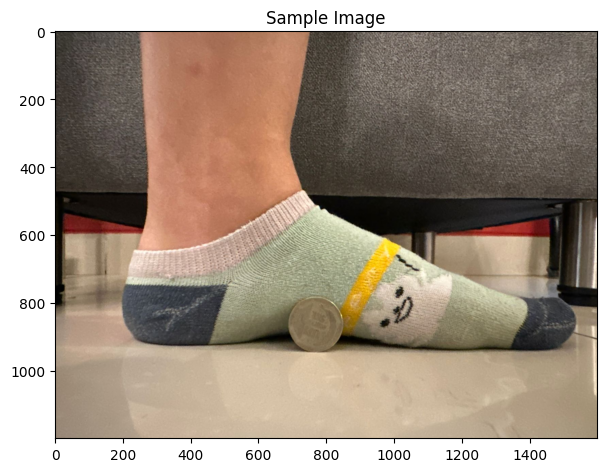

In [96]:
image = cv2.imread(image_path) # foot2
#gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
show_image(image_rgb, 'Sample Image',)

## Getting the centroids of each object (foot and coin)


image 1/1 /Users/gipo/my-stuff/MIT/shoe-sizer/experiments/../assets/37_angelica_left_7.jpeg: 1152x1504 1 coin, 1 foot, 173.1ms
Speed: 11.5ms preprocess, 173.1ms inference, 1.2ms postprocess per image at shape (1, 3, 1152, 1504)


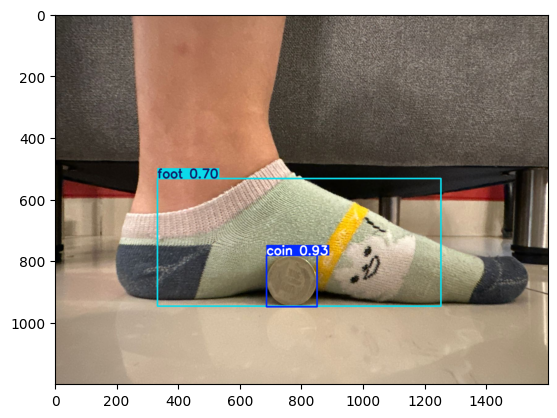

In [97]:
from ultralytics import YOLO

custom_model = YOLO("../runs/detect/train2/weights/best.pt")
inf_results = custom_model(image_path)
# Realizar inferencia
plot_pred_resutls(inf_results)

In [98]:
detections = get_best_detections(inf_results)
coin_center_x = int(detections['coin']['center'][0])
coin_center_y = int(detections['coin']['center'][1])
foot_center_x = int(detections['foot']['center'][0])
foot_center_y = int(detections['foot']['center'][1])

print(detections)
print(f"coin center: ({coin_center_x}, {coin_center_y})")
print(f"foot center: ({foot_center_x}, {foot_center_y})")

{'coin': {'center': (768.376708984375, 866.1429443359375), 'score': 0.9261959791183472}, 'foot': {'center': (792.7650756835938, 740.2037353515625), 'score': 0.6965027451515198}}
coin center: (768, 866)
foot center: (792, 740)


## Working with SAM with GPU

In [99]:
!nvidia-smi

zsh:1: command not found: nvidia-smi


In [100]:
import cv2
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamPredictor, SamAutomaticMaskGenerator

import matplotlib.pyplot as plt

In [101]:
# Load SAM model into GPU or CPU according to the device

DEVICE = ''

if machine == 'colab':
    DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
elif machine == 'mac-silicon':
    DEVICE = torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')

print(DEVICE, machine)

sam_checkpoint = f"{models_path}/sam_vit_h_4b8939.pth"

sam = sam_model_registry['vit_h'](checkpoint=sam_checkpoint).to(device=DEVICE)
mask_generator = SamAutomaticMaskGenerator(sam) # warning



mps mac-silicon


##### Loading the weights into the GPU on Mac Silicon

device = torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')
model_type = 'vit_h'
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

#### Helper Functions

In [102]:
COIN_DIAMETER_MM = 25.5

def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, primary_color='green', marker_size=250): #375)
    pos_points = coords[labels == 1]
    neg_points = coords[labels == 0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color=primary_color, marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)

def get_foot_width_cm(coin_width_px, foot_width_px):
    foot_width_mm = (foot_width_px * COIN_DIAMETER_MM)/coin_width_px
    return foot_width_mm / 10

def get_foot_size(foot_width_cm):
    return foot_width_cm * 1.5 + 1.5

foot_width_mm = get_foot_width_cm(50, 520)
print(foot_width_mm)
print(get_foot_size(foot_width_mm))

26.52
41.28


In [103]:
# image = cv2.imread(image_path)
# image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
# show_image(image_rgb, "foot")
image_rgb.shape

(1200, 1600, 3)

### Resizing the image to avoid memory issues

Reduce the image's resolution to a manageable size

In [104]:
# from PIL import Image

# max_resolution = (1024, 1024)
# image_pil = Image.fromarray(image_rgb)
# image_resized = image_pil.resize(max_resolution)
# image_rgb = np.array(image_resized)
# image_rgb.shape

In [105]:
predictor = SamPredictor(sam)
predictor.set_image(image_rgb)

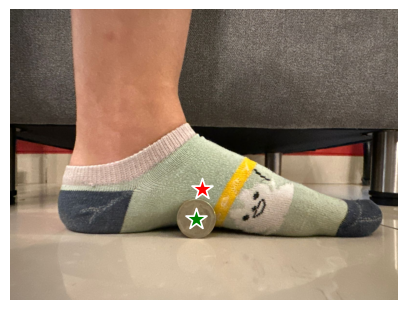

In [106]:
# Original points: foot -> np.array([[2000, 3000]]) , coin -> np.array([[3650, 3300]])
coin_input_point = np.array([[coin_center_x, coin_center_y]])
coin_input_label = np.array([1])

foot_input_point = np.array([[foot_center_x, foot_center_y]]) 
foot_input_label = np.array([1])

plt.figure(figsize=(5,5))
plt.imshow(image_rgb)
show_points(coin_input_point, coin_input_label, plt.gca(), 'green')
show_points(foot_input_point, foot_input_label, plt.gca(), 'red')
plt.axis('off')
plt.show()

##### Extrating coin masks

In [107]:
coin_masks, coin_scores, coin_logits = predictor.predict(
    point_coords=coin_input_point,
    point_labels=coin_input_label,
    multimask_output=True
)
print(coin_masks.shape) # (number_of_masks) x H x W
print(coin_scores.shape)

(3, 1200, 1600)
(3,)


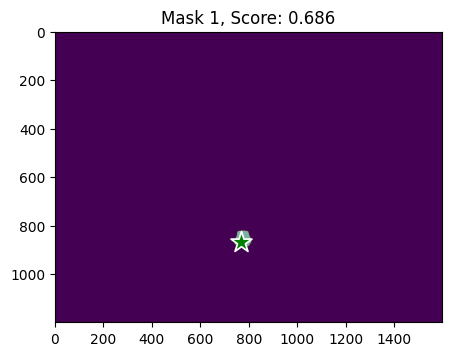

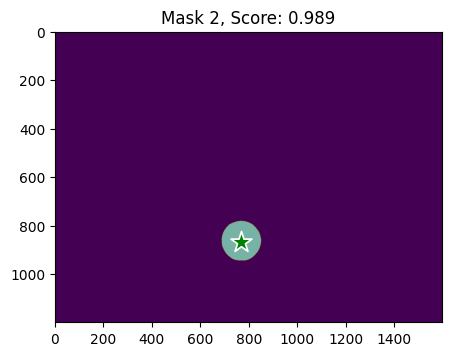

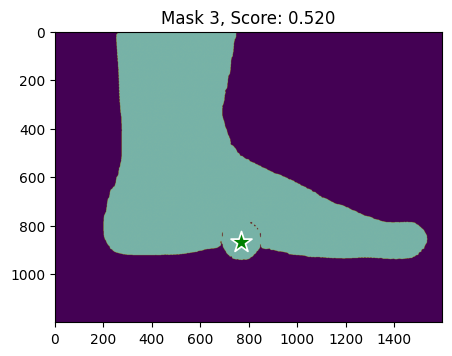

In [108]:
for i, (mask, score) in enumerate(zip(coin_masks, coin_scores)):
    plt.figure(figsize=(5, 5))
    plt.imshow(mask)
    show_mask(mask, plt.gca())
    show_points(coin_input_point, coin_input_label, plt.gca())
    plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=12)
    plt.axis('on')
    plt.show()

**Getting the best mask**

In [109]:
coin_masks_dict =[ {'mask': m, 'score': s} for m, s in zip(coin_masks, coin_scores)]
coin_masks_dict.sort(reverse=True, key=lambda x: x['score'])
coin_best_mask = coin_masks_dict[0]
coin_best_mask

{'mask': array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]),
 'score': 0.98870754}

##### Extrating foot masks 

In [110]:
foot_masks, foot_scores, foot_logits = predictor.predict(
    point_coords=foot_input_point,
    point_labels=foot_input_label,
    multimask_output=True
)
print(foot_masks.shape) # (number_of_masks) x H x W
print(foot_scores.shape)

(3, 1200, 1600)
(3,)


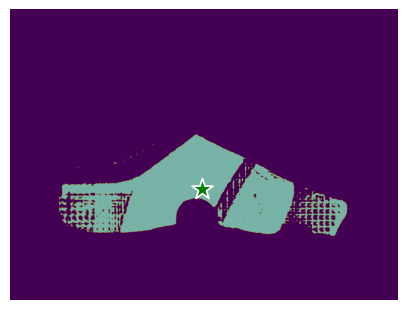

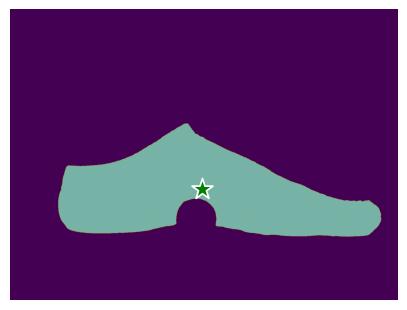

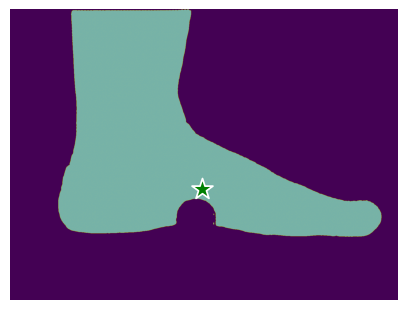

In [111]:
for i, (mask, score) in enumerate(zip(foot_masks, foot_scores)):
    plt.figure(figsize=(5, 5))
    plt.imshow(mask)
    show_mask(mask, plt.gca())
    show_points(foot_input_point, foot_input_label, plt.gca())
    #plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=12)
    plt.axis('off')
    plt.show()

In [112]:
foot_masks_dict =[ {'mask': m, 'score': s} for m, s in zip(foot_masks, foot_scores)]
foot_masks_dict.sort(reverse=True, key=lambda x: x['score'])
foot_best_mask = foot_masks_dict[0]
foot_best_mask

{'mask': array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]),
 'score': 0.9962914}

#### Getting the position of the selected mask

In [113]:
def get_object_properties(mask):
    # Encuentra los índices donde el valor es True
    indices = np.argwhere(mask)

    # Si la máscara contiene valores True, calcula las propiedades
    if indices.size > 0:
        y_min, x_min = indices.min(axis=0)  # Coordenadas superiores izquierda
        y_max, x_max = indices.max(axis=0)  # Coordenadas inferiores derecha

        coord_x = x_min
        coord_y = y_min
        width = x_max - x_min + 1  # +1 para incluir el tamaño total
        height = y_max - y_min + 1  # +1 para incluir el tamaño total

        return coord_x, coord_y, width, height
    else:
        # Si no hay valores True, retorna None o valores por defecto
        return None, None, 0, 0


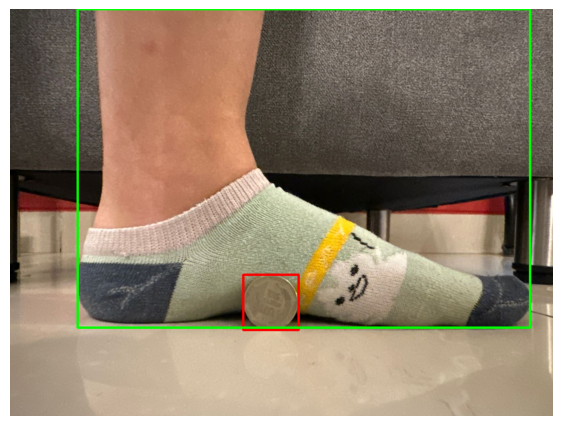

In [116]:
# Find the bounding box of the mask
# coin_coords = cv2.findContours(coin_best_mask['mask'].astype("uint8"), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# coin_contour = coin_coords[0][0]
# coin_x, coin_y, coin_w, coin_h = cv2.boundingRect(coin_contour)

# foot_coords = cv2.findContours(foot_best_mask['mask'].astype("uint8"), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# foot_contour = foot_coords[0][0]
# foot_x, foot_y, foot_w, foot_h = cv2.boundingRect(foot_contour)

coin_x, coin_y, coin_w, coin_h = get_object_properties(coin_best_mask['mask'])
foot_x, foot_y, foot_w, foot_h = get_object_properties(foot_best_mask['mask'])


# Draw the bounding box on the image
image_with_box = image_rgb.copy()
cv2.rectangle(image_with_box, (coin_x, coin_y), (coin_x + coin_w, coin_y + coin_h), (255, 0, 0), 6)
cv2.rectangle(image_with_box, (foot_x, foot_y), (foot_x + foot_w, foot_y + foot_h), (0, 255, 0), 6)

plt.figure(figsize=(7, 7))
plt.imshow(image_with_box)
plt.axis('off')
plt.show()

In [26]:
# cv2.imwrite('my_image_with_box.png', image_with_box)

In [27]:
def get_foot_width_cm(coin_width_px, foot_width_px):
    pixels_per_mm = coin_width_px / COIN_DIAMETER_MM
    foot_width_mm = foot_width_px / pixels_per_mm
    foot_width_cm = foot_width_mm / 10
    return foot_width_cm 

def calcular_tamanio_pie_cm(diametro_moneda_px, ancho_pie_px):
    # Constante: diámetro real de la moneda en milímetros
    DIAMETRO_MONEDA_MM = 25.5
    # Calcular la relación de píxeles a milímetros
    relacion_px_mm = DIAMETRO_MONEDA_MM / diametro_moneda_px

    # Calcular el ancho del pie en milímetros
    ancho_pie_mm = ancho_pie_px * relacion_px_mm

    # Convertir el ancho del pie a centímetros
    ancho_pie_cm = ancho_pie_mm / 10

    return ancho_pie_cm

print(get_foot_size(26.2))

40.8


In [28]:
print(f"coin width: {coin_w}px")
print(f"coin height: {coin_h}px")
print(f"foot width: {foot_w}px")

foot_width_cm = get_foot_width_cm(coin_width_px=coin_w, foot_width_px=foot_w)
foot_size_eu = get_foot_size(foot_width_cm)

print(f"Size cm: {foot_width_cm}")
print(f"Size cm: {calcular_tamanio_pie_cm(coin_w, foot_w)}")
print(f"EU size: {foot_size_eu}")


coin width: 97px
coin height: 101px
foot width: 825px
Size cm: 21.688144329896907
Size cm: 21.688144329896907
EU size: 34.03221649484536


#### Isolate the selected feet mask

In [29]:
foot_best_mask['mask']

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

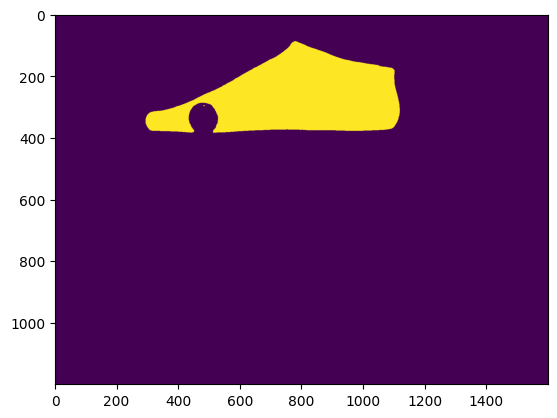

In [30]:
plt.imshow(foot_best_mask['mask'])

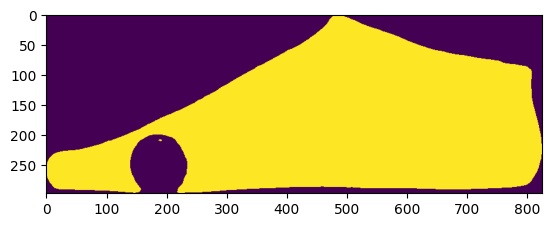

In [31]:
coords = np.where(foot_best_mask['mask'])
y_min, y_max = coords[0].min(), coords[0].max() # vertical axis
x_min, x_max = coords[1].min(), coords[1].max() # horizontal axis

cropped_mask = foot_best_mask['mask'][y_min: y_max + 1, x_min: x_max + 1]
plt.imshow(cropped_mask)
plt.show()

### Cropping the image in half

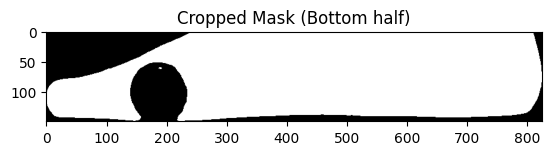

In [32]:
def crop_half_mask(mask):
    # Validar que la máscara sea una matriz numpy
    if not isinstance(mask, np.ndarray):
        raise ValueError("La máscara de entrada debe ser un numpy.ndarray.")

    # Verificar dimensiones (2D o 3D)
    if mask.ndim < 2:
        raise ValueError("La máscara debe tener al menos dos dimensiones (alto y ancho).")
    
    # Calcular la altura para el recorte
    height = mask.shape[0]
    half_height = height // 2

    # Recortar la mitad inferior de la máscara
    cropped_mask = mask[half_height:, :]
    return cropped_mask


cropped_half_mask = crop_half_mask(cropped_mask)

plt.imshow(cropped_half_mask, cmap="gray")
plt.title("Cropped Mask (Bottom half)")
plt.axis("on")
plt.show()

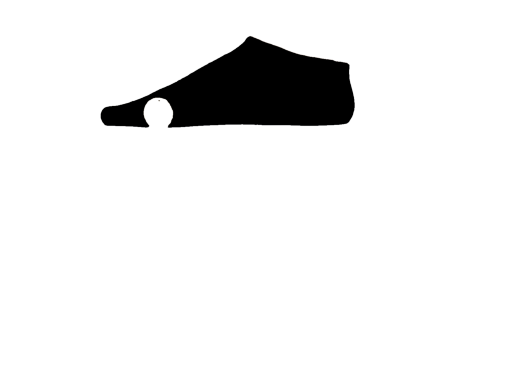

In [33]:
def mask_to_image(mask, image_rgb):
    result_image = np.zeros((image_rgb.shape[0], image_rgb.shape[1], 4), dtype=np.uint8)
    result_image[..., :3] = image_rgb
    result_image[..., 3] = (mask * 255).astype(np.uint8)
    result_image[mask == 1, :3] = [0, 0, 0] # set all the segment (mask) to 0,0,0
    plt.imshow(result_image)
    plt.axis("off")
    plt.show()

black_mask = mask_to_image(foot_best_mask['mask'], image_rgb)

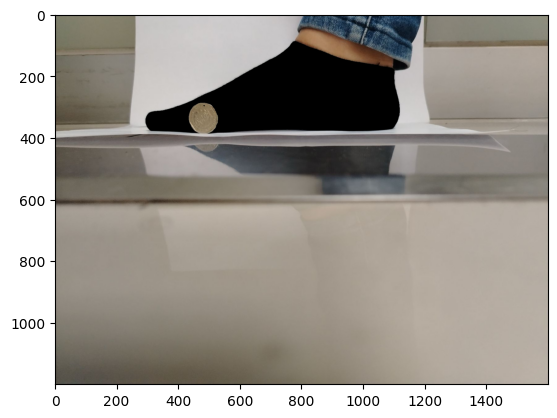

In [34]:
def mask_to_black(mask, image_rgb):
    # Crear una copia de la imagen original
    result_image = image_rgb.copy()
    
    # Asignar valores negros (0, 0, 0) a los píxeles seleccionados por la máscara
    result_image[mask == 1] = [0, 0, 0]  # Píxeles negros en la región de la máscara
    plt.imshow(result_image)
    plt.axis("on")
    plt.show()
    
    #return result_image
mask_to_black(foot_best_mask['mask'], image_rgb)

In [35]:
#mask_generator = SamAutomaticMaskGenerator(sam) # warning

In [36]:
# masks_gen = mask_generator.generate(image_rgb)
# plt.figure(figsize=(8,8))
# plt.imshow(image_rgb)
# plt.show()

#print(masks_gen[0])

In [37]:
# optimize memory
# torch.cuda.empty_cache()
# torch.cuda.reset_peak_memory_stats()

## Batch Generate Dataset

In [38]:
import os
import csv

from ultralytics import YOLO


def save_to_csv(csv_path, data: dict):
    file_exists = os.path.exists(csv_path)
    with open(csv_path, mode='a', newline='') as csv_file:
        writer = csv.DictWriter(csv_file, fieldnames=data.keys())
        if not file_exists:
            # Write header if the file doesn't exist
            writer.writeheader()
        # Write image data
        writer.writerow(data)
        
def process_images(input_dir, output_dir, csv_path, suffix=""):
    # Ensure the output directory exists
    os.makedirs(output_dir, exist_ok=True)

    custom_model = YOLO("../runs/detect/train2/weights/best.pt")

    count = 0
    # Traverse input directory
    for root, _, files in os.walk(input_dir):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                file_path = os.path.join(root, file)
                try:
                    # Load the image
                    image = cv2.imread(file_path)
                    
                    if image is None:
                        print(f"Failed to load image: {file_path}")
                        continue
                    
                    # Get image dimensions
                    height, width = image.shape[:2]

                    #### Transformations
                    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

                    inf_results = custom_model(image)

                    plot_resutls = inf_results[0].plot()
                    labeled_image = cv2.cvtColor(plot_resutls, cv2.COLOR_BGR2RGB)

                    detections = get_best_detections(inf_results)
                    coin_center_x = int(detections['coin']['center'][0])
                    coin_center_y = int(detections['coin']['center'][1])
                    foot_center_x = int(detections['foot']['center'][0])
                    foot_center_y = int(detections['foot']['center'][1])
                    
                    # Apply transformations (example: convert to grayscale)
                    #transformed_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

                    #### Adding current image to the SAM context
                    predictor = SamPredictor(sam)
                    predictor.set_image(image_rgb)

                    #### Pointing the center of each object
                    coin_input_point = np.array([[coin_center_x, coin_center_y]])
                    coin_input_label = np.array([1])
                    foot_input_point = np.array([[foot_center_x, foot_center_y]]) 
                    foot_input_label = np.array([1])


                    #### Getting the best mask of each object
                    # coin
                    coin_masks, coin_scores, coin_logits = predictor.predict(
                        point_coords=coin_input_point,
                        point_labels=coin_input_label,
                        multimask_output=True
                    )
                    coin_masks_dict =[ {'mask': m, 'score': s} for m, s in zip(coin_masks, coin_scores)]
                    coin_masks_dict.sort(reverse=True, key=lambda x: x['score'])
                    coin_best_mask = coin_masks_dict[0]

                    # foot
                    foot_masks, foot_scores, foot_logits = predictor.predict(
                        point_coords=foot_input_point,
                        point_labels=foot_input_label,
                        multimask_output=True
                    )
                    foot_masks_dict =[ {'mask': m, 'score': s} for m, s in zip(foot_masks, foot_scores)]
                    foot_masks_dict.sort(reverse=True, key=lambda x: x['score'])
                    foot_best_mask = foot_masks_dict[0]


                    ### Drawing the centroids of each object
                    coin_x, coin_y, coin_w, coin_h = get_object_properties(coin_best_mask['mask'])
                    foot_x, foot_y, foot_w, foot_h = get_object_properties(foot_best_mask['mask'])
                    image_with_box = image_rgb.copy()
                    cv2.rectangle(image_with_box, (coin_x, coin_y), (coin_x + coin_w, coin_y + coin_h), (255, 0, 0), 2)
                    cv2.rectangle(image_with_box, (foot_x, foot_y), (foot_x + foot_w, foot_y + foot_h), (0, 255, 0), 2)
                    
                    # Create output path
                    relative_path = os.path.relpath(root, input_dir)
                    output_subdir = os.path.join(output_dir, relative_path)
                    os.makedirs(output_subdir, exist_ok=True)
                    
                    output_labeled_file = f"{os.path.splitext(file)[0]}{suffix}_lbl.png"
                    output_labeled_path = os.path.join(output_subdir, output_labeled_file)
                    output_result_file = f"{os.path.splitext(file)[0]}{suffix}_res.png"
                    output_result_path = os.path.join(output_subdir, output_result_file)
                    
                    labeled_image = cv2.cvtColor(labeled_image, cv2.COLOR_RGB2BGR)
                    image_with_box = cv2.cvtColor(image_with_box, cv2.COLOR_RGB2BGR)
                    # Save the detected object image
                    cv2.imwrite(output_labeled_path, labeled_image)
                    # Save the resulting image
                    cv2.imwrite(output_result_path, image_with_box)
                    
                    # Log details to CSV
                    relative_filename = os.path.join(relative_path, file)
                    row_process = {
                        "img_name": file, 
                        "img_width": width, 
                        "img_height": height,
                        "coin_width": coin_w,
                        "coin_height": coin_h,
                        "foot_width": foot_w
                    }
                    save_to_csv(csv_path, data=row_process)
                    count += 1
                
                except Exception as e:
                    print(f"Error processing {file_path}: {e}")

In [40]:

base_path = '../data'
input_path = f'{base_path}/new_feet_images' # feet_images
output_path = f'{base_path}/result_images'
csv_file_path = f'{base_path}/new_feet_dataset.csv' # feet_dataset.csv

models_path = '../models'

process_images(input_path, output_path, csv_file_path, suffix="")


0: 1152x1504 2 coins, 182.5ms
Speed: 36.2ms preprocess, 182.5ms inference, 14.1ms postprocess per image at shape (1, 3, 1152, 1504)
Error processing ../data/new_feet_images/37_angelica_left/37_angelica_left_8.jpeg: 'NoneType' object is not subscriptable

0: 1152x1504 1 coin, 2 foots, 172.0ms
Speed: 7.8ms preprocess, 172.0ms inference, 1.6ms postprocess per image at shape (1, 3, 1152, 1504)

0: 1152x1504 2 coins, 1 foot, 217.9ms
Speed: 14.8ms preprocess, 217.9ms inference, 0.7ms postprocess per image at shape (1, 3, 1152, 1504)

0: 1152x1504 1 coin, 2 foots, 150.7ms
Speed: 8.4ms preprocess, 150.7ms inference, 1.9ms postprocess per image at shape (1, 3, 1152, 1504)

0: 1152x1504 2 coins, 3 foots, 142.4ms
Speed: 10.4ms preprocess, 142.4ms inference, 0.8ms postprocess per image at shape (1, 3, 1152, 1504)

0: 1152x1504 1 coin, 1 foot, 133.5ms
Speed: 8.1ms preprocess, 133.5ms inference, 0.4ms postprocess per image at shape (1, 3, 1152, 1504)

0: 1152x1504 2 coins, 2 foots, 140.5ms
Speed: 7